
📂 6 fichiers trouvés dans : Z:\forgetting\Carla\OpenEphysData\Opto_stim\RondViolet\RH_0


✅ Figure sauvegardée : Z:\forgetting\Carla\OpenEphysData\Opto_stim\RondViolet\RH_0\Superposition_RH_0_RondViolet.png


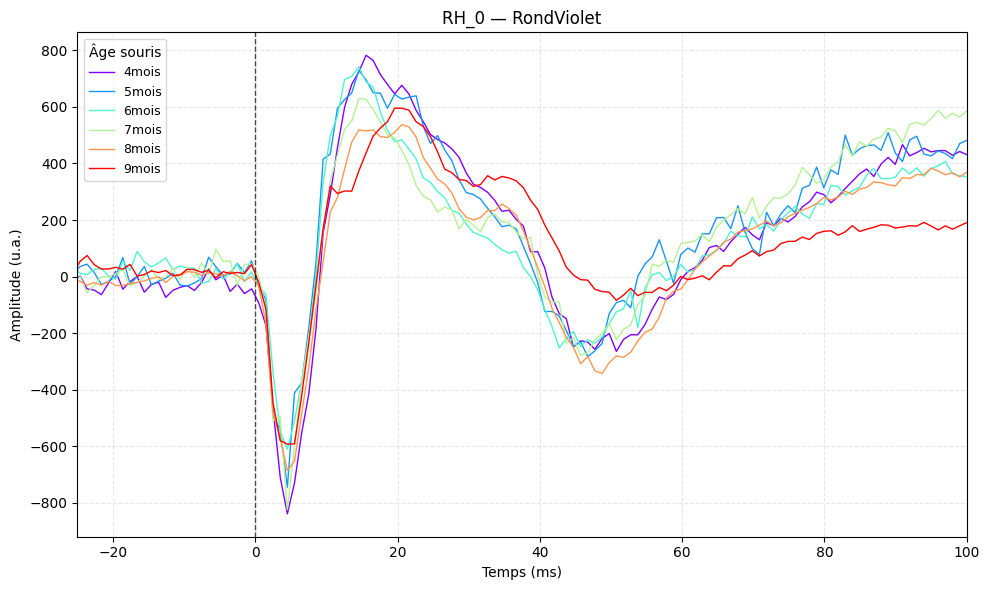

In [18]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import re

# === DÉFINIR LE DOSSIER CONTENANT LES FICHIERS PKL ===
folder_path = Path("Z:/forgetting/Carla/OpenEphysData/Opto_stim/RondViolet/RH_0")

# === RÉCUPÉRER TOUS LES FICHIERS PKL ===
pkl_files = sorted(folder_path.glob("*.pkl"))

if not pkl_files:
    print("⚠️ Aucun fichier .pkl trouvé dans ce dossier.")
    exit()

print(f"\n📂 {len(pkl_files)} fichiers trouvés dans : {folder_path}\n")

# === FONCTION POUR EXTRAIRE LE MOIS DU NOM DU FICHIER ===
def extract_mois_from_filename(path):
    match = re.search(r'_(\d+mois)_', path.stem)
    if match:
        return match.group(1)  # ex: "4mois"
    else:
        return "Inconnu"

# === FONCTION POUR EXTRAIRE LE NOM DE LA SOURIS ===
def extract_mouse_from_filename(path):
    parts = path.stem.split('_')
    for i, part in enumerate(parts):
        if re.match(r'\d{4}-\d{2}-\d{2}', part):  # trouve la date
            return parts[i-1]  # mot juste avant la date
    return "Inconnu"

mouse_name = extract_mouse_from_filename(pkl_files[0])  # prend la première souris comme exemple

# === CHOIX DU DÉGRADÉ DE COULEURS ARC-EN-CIEL ===
colors = plt.cm.rainbow(np.linspace(0, 1, len(pkl_files)))  # arc-en-ciel du rouge → violet

# === PLOT ===
fig, ax = plt.subplots(figsize=(10, 6))

for color, file in zip(colors, pkl_files):
    with open(file, 'rb') as f:
        data = pickle.load(f)
    mois = extract_mois_from_filename(file)
    ax.plot(data['time_axis'], data['mean_signal'], linewidth=1, color=color, label=mois)

# === MISE EN FORME DU GRAPHE ===
ax.axvline(x=0, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax.set(
    xlabel="Temps (ms)",
    ylabel="Amplitude (u.a.)",
    title=f"{data['region']} — {mouse_name}",  # <-- Titre mis à jour
    xlim=(-25, 100)
)
ax.legend(title="Âge souris", fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# === SAUVEGARDE AUTOMATIQUE EN PNG ===
save_path = folder_path / f"Superposition_{data['region']}_{mouse_name}.png"
plt.savefig(save_path, dpi=300)
print(f"\n✅ Figure sauvegardée : {save_path}")

plt.show()
